# d · La méthode « Under Pressure »

L'équipe *Under Pressure* a fini première de BattLeDIM sur les fuites trouvées : 15 fuites sur 23
en 2019, 4 fausses alarmes, 260 562 € (Steffelbauer et al., *J. Water Resour. Plann. Manage.*, 2022).
Ce carnet refait leur méthode sur notre modèle calibré.

Leur méthode, dans l'ordre :

1. **calibrer** les demandes et les rugosités ;
2. construire le **modèle dual** : chaque capteur de pression est relié à un réservoir virtuel ;
3. **détecter** sur les débits virtuels, avec des seuils pris sur la première semaine de 2018 ;
4. ajuster la **forme** de chaque fuite (casse brutale, ou fuite qui grandit puis plafonne) ;
5. **localiser** par corrélation de Pearson avec les sensibilités des capteurs ;
6. ajouter la fuite trouvée au modèle comme demande connue, et **recommencer** pour la suivante.

L'étape 1 est déjà faite : notre modèle calibré (`02_calibration_modele`) reprend leur modèle de
demande ; pour les rugosités, il a 13 groupes au lieu de leurs 6. Ce carnet fait les étapes 2 à 6.

Les débitmètres servent trois fois, comme dans l'article : le réseau est coupé à la pompe (§1), le
bilan de débit de chaque zone donne la forme des fuites (§6), et il confirme chaque alarme.

Le code est dans `detection/dual.py` (le modèle dual) et `detection/under_pressure.py` (la boucle).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from detection import residu as Rs, lentes as Le, dual as Du, under_pressure as U, bareme as B, localisation as L
from detection.residu import R, M

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

## Réglages

In [2]:
ANNEE = 2018
PROCESSUS = 4          # simulations en parallèle pour l'année (1 = une à une)
LISSAGE = "4h"         # moyenne glissante de leurs figures
SEMAINE = slice("2018-01-01", "2018-01-07")   # la semaine qu'ils supposent sans fuite

## 1. Le modèle dual

Dans notre modèle habituel, on donne la demande de chaque nœud et le modèle calcule les pressions.
Le modèle dual fait l'inverse aux 33 capteurs : on **impose** la pression mesurée, avec un réservoir
virtuel relié au capteur. Le modèle calcule alors le débit qui part vers chaque réservoir virtuel.

- Si le modèle explique les mesures, ce débit est nul.
- S'il manque de l'eau dans le réseau (une fuite), la pression mesurée est plus basse que prévu ;
  l'eau part vers le réservoir virtuel du capteur voisin : c'est le **débit de fuite virtuel** `q_v`.

**Contrôle.** Si on impose aux capteurs les pressions du modèle calibré lui-même, il ne manque rien :
`q_v` doit être nul. (Ce contrôle garde la pompe du modèle : voir plus bas.)

In [3]:
fen2 = M.fenetre(ANNEE, 0, 2)
sain = Rs.simuler_annee(ANNEE).to_numpy()[:fen2.n_pas]     # les pressions du modèle, sans fuite
q_controle = Du.simuler(fen2, sain, separer=False)
print(f"|q_v| moyen {np.abs(q_controle).mean():.4f} m³/h, maximum {np.abs(q_controle).max():.2f} m³/h")

|q_v| moyen 0.0017 m³/h, maximum 4.53 m³/h


Presque nul. Le maximum vient du tout premier pas de chaque tranche de 6 h, le temps que le
réservoir T1 se recale.

**Le réseau coupé à la pompe.** L'article coupe le réseau en deux : côté A+B, la pompe est remplacée
par son **débit mesuré** ; côté C, le réservoir T1 est tenu à son **niveau mesuré**. Chaque zone n'a
plus que des mesures pour frontières. Ce que ça change, sur la première semaine (sans fuite) :

In [4]:
fen7 = M.fenetre(ANNEE, 0, 7)
zones7 = Rs.zones_des_capteurs(fen7.capteurs)
for separer in (False, True):
    q = pd.DataFrame(Du.simuler(fen7, fen7.p_mes, separer=separer), index=fen7.horo, columns=fen7.capteurs)
    for z in ("AB", "C"):
        s = q[[c for c in q.columns if zones7[c] == z]].sum(axis=1).resample("1h").mean()
        print(f"coupé = {separer!s:5s} zone {z:2s} : somme des q_v, écart-type horaire {s.std():.2f} m³/h")

coupé = False zone AB : somme des q_v, écart-type horaire 2.54 m³/h
coupé = False zone C  : somme des q_v, écart-type horaire 1.27 m³/h


coupé = True  zone AB : somme des q_v, écart-type horaire 2.54 m³/h
coupé = True  zone C  : somme des q_v, écart-type horaire 0.31 m³/h


Côté C, le bruit est divisé par deux et demi : la pompe du modèle ne suit pas exactement la vraie.
Côté A+B, rien ne change. Toute la suite utilise le réseau coupé.

## 2. Les débits virtuels de l'année

Maintenant, les pressions **mesurées**. Une vingtaine de minutes la première fois (avec un
processus), puis lu dans `sorties/`.

In [5]:
qv = Du.debits_virtuels(ANNEE, processus=PROCESSUS)
zones = Rs.zones_des_capteurs(qv.columns)
capteurs_de = {z: [c for c in qv.columns if zones[c] == z] for z in ("AB", "C")}
print(qv.shape, "| moyenne par capteur (m³/h) :")
print(qv.mean().round(2).sort_values().to_string())

(105120, 33) | moyenne par capteur (m³/h) :
n636   -1.58
n740   -1.17
n332   -0.53
n722   -0.47
n415   -0.30
n549   -0.26
n506   -0.12
n410   -0.02
n296    0.03
n458    0.05
n519    0.17
n679    0.25
n215    0.25
n516    0.38
n469    0.50
n105    0.61
n429    0.65
n288    0.67
n31     0.69
n4      0.77
n769    0.77
n495    0.78
n163    0.80
n726    0.97
n644    1.00
n342    1.07
n114    1.25
n752    1.43
n229    1.69
n188    2.07
n54     2.10
n613    2.52
n1      3.74


## 3. La somme des débits virtuels ≈ la fuite

L'article : « la somme de tous les débits virtuels donne une bonne première estimation de la taille
de la fuite ». On la compare, zone par zone :

- au **bilan de débit** de la zone (ce qui entre, moins la consommation du modèle) : c'est une mesure ;
- aux **vraies fuites** du fichier publié : on ne s'en sert que pour vérifier.

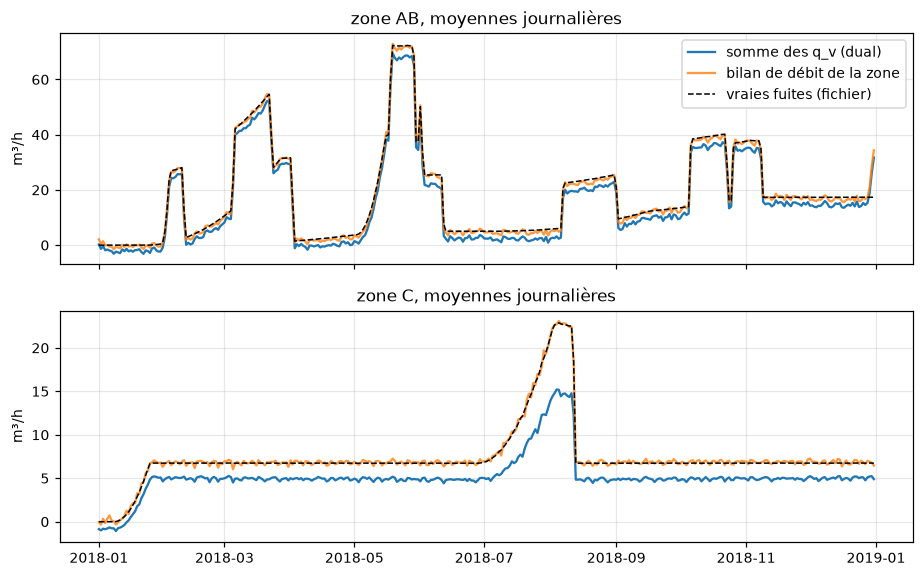

In [6]:
bilan = Le.fuite_par_zone(ANNEE)
fuites, debits = Rs.fuites_publiees(ANNEE)
vraie = {z: debits[list(fuites.index[fuites.zone == z])].sum(axis=1) for z in ("AB", "C")}

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, z in zip(axes, ("AB", "C")):
    ax.plot(qv[capteurs_de[z]].sum(axis=1).resample("1D").mean(), label="somme des q_v (dual)")
    ax.plot(bilan[z].resample("1D").mean(), label="bilan de débit de la zone", alpha=0.8)
    ax.plot(vraie[z].resample("1D").mean(), "k--", lw=1, label="vraies fuites (fichier)")
    ax.set(ylabel="m³/h", title=f"zone {z}, moyennes journalières")
axes[0].legend();

In [7]:
for z in ("AB", "C"):
    s = qv[capteurs_de[z]].sum(axis=1).resample("1D").mean()
    v = vraie[z].resample("1D").mean().reindex(s.index)
    b = bilan[z].resample("1D").mean().reindex(s.index)
    print(f"zone {z} : somme q_v − vraies fuites = {(s - v).mean():+5.1f} ± {(s - v).std():4.1f} m³/h | "
          f"bilan − vraies fuites = {(b - v).mean():+5.1f} ± {(b - v).std():4.1f} m³/h | "
          f"corrélation somme/vraies {np.corrcoef(s, v)[0, 1]:.2f}")

zone AB : somme q_v − vraies fuites =  -2.7 ±  1.4 m³/h | bilan − vraies fuites =  -0.3 ±  1.3 m³/h | corrélation somme/vraies 1.00
zone C : somme q_v − vraies fuites =  -2.1 ±  1.3 m³/h | bilan − vraies fuites =  +0.1 ±  0.2 m³/h | corrélation somme/vraies 0.99


La somme des débits virtuels suit les vraies fuites jour après jour, comme le bilan de débit. Elle
les sous-estime un peu (2,7 m³/h en AB, 1,1 m³/h en C, et la grosse fuite p31 de l'été en C : 18
au lieu de 23 m³/h). L'article fait la même remarque : « le modèle dual semble sous-estimer un peu
les vraies fuites ».

## 4. Un signal localisé

L'autre promesse : la fuite fait réagir surtout le capteur **le plus proche**, alors que la pression
baisse partout. On regarde chaque fuite au moment où elle grandit le plus en 24 h (une fuite lente
commence à quelques dixièmes de m³/h : à son tout début, il n'y a rien à voir). Deux exemples
d'abord : p232 (zone AB) et p31 (zone C, le cas de leur figure 4).

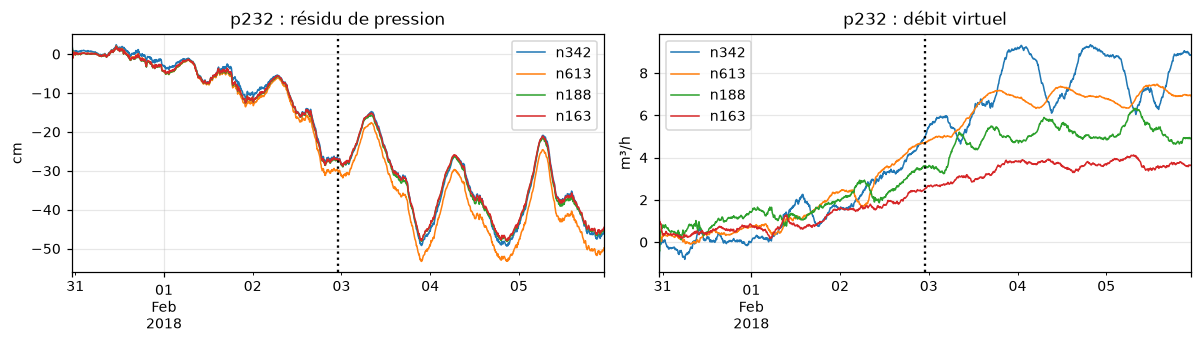

marche de q_v sur 24 h (m³/h), 4 plus grandes : {'n342': 3.3, 'n613': 2.8, 'n188': 1.9, 'n163': 1.2}


In [8]:
res = Rs.residu(ANNEE)          # pression mesurée − modèle, cm

def instant(p):
    # l'heure où la fuite grandit le plus : moyenne des 24 h après − moyenne des 24 h avant
    # (fichier publié, pour vérifier seulement)
    h = debits[p]
    apres = h[::-1].rolling(24).mean()[::-1]
    avant = h.rolling(24).mean().shift(1)
    return (apres - avant).idxmax()

def avant_apres(p, jours=3):
    t = instant(p)
    fen = slice(t - pd.Timedelta(days=jours), t + pd.Timedelta(days=jours))
    cap = capteurs_de[fuites.zone[p]]
    q = qv.loc[fen, cap].rolling(LISSAGE).mean()
    r = res.loc[fen, cap].rolling(LISSAGE).mean()
    marche = (q.loc[t:t + pd.Timedelta(days=1)].mean() - q.loc[t - pd.Timedelta(days=1):t].mean())
    top = list(marche.sort_values(ascending=False).index[:4])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    r[top].plot(ax=axes[0], lw=1); axes[0].set(ylabel="cm", title=f"{p} : résidu de pression")
    q[top].plot(ax=axes[1], lw=1); axes[1].set(ylabel="m³/h", title=f"{p} : débit virtuel")
    for ax in axes:
        ax.axvline(t, color="k", ls=":")
    plt.tight_layout(); plt.show()
    return marche

marche = avant_apres("p232")
print("marche de q_v sur 24 h (m³/h), 4 plus grandes :", marche.sort_values(ascending=False).head(4).round(1).to_dict())

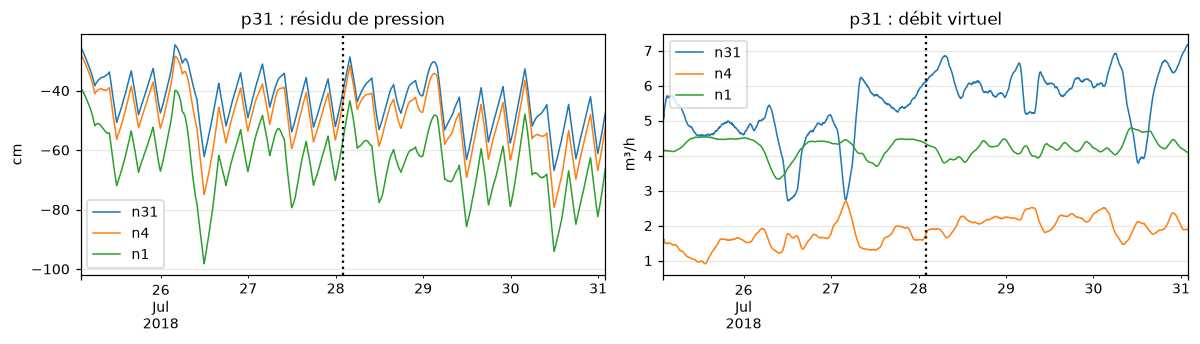

marche de q_v sur 24 h (m³/h), 4 plus grandes : {'n31': 0.8, 'n4': 0.3, 'n1': -0.1}


In [9]:
marche = avant_apres("p31")
print("marche de q_v sur 24 h (m³/h), 4 plus grandes :", marche.sort_values(ascending=False).head(4).round(1).to_dict())

In [10]:
# pour chaque fuite : la marche de q_v sur 24 h, et la part qu'en porte le capteur qui réagit le plus
# (même chose pour la baisse de pression)
for p in fuites.index:
    t, cap = instant(p), capteurs_de[fuites.zone[p]]
    dq = debits[p].loc[t:t + pd.Timedelta(days=1)].mean() - debits[p].loc[t - pd.Timedelta(days=1):t].mean()
    if dq < 2:
        print(f"{p:5s} {fuites.zone[p]:2s} grandit de moins de 2 m³/h en un jour : pas de marche à mesurer")
        continue
    if t < qv.index[0] + pd.Timedelta(days=2):
        continue
    mq = (qv.loc[t:t + pd.Timedelta(days=1), cap].mean() - qv.loc[t - pd.Timedelta(days=1):t, cap].mean())
    mr = (res.loc[t - pd.Timedelta(days=1):t, cap].mean() - res.loc[t:t + pd.Timedelta(days=1), cap].mean())
    part = lambda m: m.max() / max(m.clip(lower=0).sum(), 1e-9)
    print(f"{p:5s} {fuites.zone[p]:2s} hausse de la fuite {dq:5.1f} m³/h | somme des marches q_v {mq.sum():6.1f} m³/h | "
          f"part du 1er capteur : q_v {part(mq):.2f}, pression {part(mr):.2f}")

p31   C  grandit de moins de 2 m³/h en un jour : pas de marche à mesurer
p158  AB hausse de la fuite  23.1 m³/h | somme des marches q_v   23.7 m³/h | part du 1er capteur : q_v 0.63, pression 0.09
p183  AB hausse de la fuite  15.3 m³/h | somme des marches q_v   15.8 m³/h | part du 1er capteur : q_v 0.50, pression 0.09
p232  AB hausse de la fuite  10.9 m³/h | somme des marches q_v   10.4 m³/h | part du 1er capteur : q_v 0.30, pression 0.06
p257  C  grandit de moins de 2 m³/h en un jour : pas de marche à mesurer
p369  AB hausse de la fuite  19.8 m³/h | somme des marches q_v   20.8 m³/h | part du 1er capteur : q_v 0.44, pression 0.09
p427  AB grandit de moins de 2 m³/h en un jour : pas de marche à mesurer
p461  AB grandit de moins de 2 m³/h en un jour : pas de marche à mesurer
p538  AB hausse de la fuite  30.6 m³/h | somme des marches q_v   30.4 m³/h | part du 1er capteur : q_v 0.31, pression 0.06
p628  AB hausse de la fuite   4.7 m³/h | somme des marches q_v    5.7 m³/h | part du 1er capt

Pour les fuites qui grandissent d'au moins 2 m³/h en un jour (les casses) :

- la somme des marches de `q_v` redonne la hausse de la fuite, à 2 m³/h près, sauf p866 (15 au lieu de 20 m³/h) ;
- le capteur qui réagit le plus porte 30 à 70 % de la marche de `q_v`, contre 6 à 14 % de la baisse
  de pression. La pression baisse partout dans la zone ; le débit virtuel, surtout près de la fuite.

Les fuites lentes grandissent de moins de 1 m³/h par jour : sur une journée, il n'y a rien à voir.

## 5. Les seuils de la première semaine

Leur détection : « les seuils sont extraits des débits virtuels de chaque capteur sur la première
semaine de 2018, supposée sans fuite ; si le signal dépasse le seuil, une fuite est détectée ».

Le fichier publié permet de vérifier l'hypothèse « sans fuite » :

In [11]:
debut, fin = pd.Timestamp(SEMAINE.start), pd.Timestamp(SEMAINE.stop) + pd.Timedelta(days=1)
actives = fuites[(fuites.debut < fin) & (fuites.fin > debut)]
print("fuites actives la première semaine :", actives[["zone", "debut", "debit_max"]].to_string() if len(actives) else "aucune")

fuites actives la première semaine : aucune


Seuil de chaque capteur : le plus grand `q_v` lissé sur 4 h de la première semaine. Combien de
temps chaque capteur passe-t-il au-dessus, sur l'année ?

In [12]:
lisse = qv.rolling(LISSAGE).mean()
seuil = lisse.loc[SEMAINE].max()
dessus = (lisse > seuil).mean().sort_values(ascending=False)
print("part du temps au-dessus du seuil, 10 capteurs les plus souvent dessus :")
print(dessus.head(10).round(2).to_string())
print(f"médiane sur les 33 capteurs : {dessus.median():.2f}")

part du temps au-dessus du seuil, 10 capteurs les plus souvent dessus :
n1      0.97
n4      0.84
n31     0.60
n613    0.53
n769    0.42
n752    0.40
n726    0.39
n188    0.34
n342    0.33
n288    0.32
médiane sur les 33 capteurs : 0.17


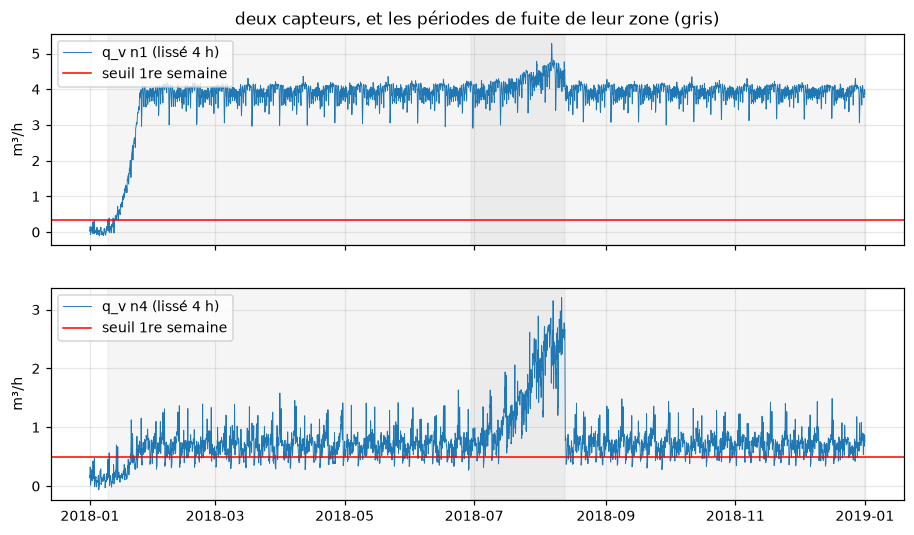

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, c in zip(axes, dessus.index[:2]):
    ax.plot(lisse[c].resample("1h").mean(), lw=0.6, label=f"q_v {c} (lissé 4 h)")
    ax.axhline(seuil[c], color="r", lw=1, label="seuil 1re semaine")
    z = zones[c]
    for p in fuites.index[fuites.zone == z]:
        ax.axvspan(fuites.debut[p], fuites.fin[p], color="grey", alpha=0.08)
    ax.set(ylabel="m³/h"); ax.legend(loc="upper left")
axes[0].set_title("deux capteurs, et les périodes de fuite de leur zone (gris)");

Une fois une fuite apparue, `q_v` reste au-dessus du seuil : les fuites de 2018 ne sont pas toutes
réparées (p257 en zone C coule toute l'année). Un seuil seul dit donc « il y a une fuite dans la
zone », pas « une **nouvelle** fuite vient d'apparaître ». C'est pour cela que leur méthode ajoute
chaque fuite trouvée au modèle avant de chercher la suivante (étape 6).

## 6. Détecter, ajuster, localiser, retirer

La boucle de l'article (`U.chaine`), fuite après fuite :

1. **détecter** : un CUSUM par capteur sur `q_v`, centré et réduit avec la première semaine ; seuil
   = 2 × le plus haut CUSUM de cette semaine (au moins 5). L'article ajoute un test du rapport de
   vraisemblance ; il est dans le code (`tests=("cusum", "rv")`), mais sur nos données il ajoute
   surtout des fausses alarmes (§8) ;
2. **vérifier et ajuster la forme** sur le bilan de débit de la zone : casse (type I) ou montée
   puis plateau (type II). La fenêtre part de l'avant-veille du départ du CUSUM ; elle finit « avant
   la fuite suivante » (l'article) : on l'allonge jour après jour, jusqu'à 14 jours, tant que le jour
   ajouté suit la courbe. Si le bilan voit moins de 1 m³/h, l'alarme est ignorée et le niveau du
   capteur devient sa nouvelle normale (notre version de leur vérification « à l'œil ») ;
3. **localiser** : à chaque heure de la fenêtre, corrélation de Pearson entre la baisse de pression
   et la signature de chaque conduite, sur les capteurs dont `q_v` a monté d'au moins 0,5 L/s ; on
   somme les corrélations au-dessus de 0,95 ; la plus grande somme gagne ;
4. **réajuster avant d'ajouter** : avant de déclarer une nouvelle fuite, on réajuste les fuites
   connues de la zone sur les nouvelles données (l'article : « la meilleure combinaison des débits
   de fuite au cours du temps »). Si une fuite connue qui grandit encore explique la hausse, on met
   sa courbe à jour, sans nouvelle alarme ;
5. **retirer** : la fuite trouvée, avec sa courbe, est soustraite de `q_v`, de la pression et du
   bilan ; on repart juste après l'alarme.

Ajout qui n'est pas dans l'article : quand le bilan d'une zone baisse franchement (une
**réparation**), la fuite connue dont le débit colle le mieux à la baisse est arrêtée.

Les réglages sont en tête de `detection/under_pressure.py`. Une vingtaine de minutes.

In [14]:
calibration = U.calibration_2018()
trouvees = U.chaine(ANNEE, calibration)

  11/01 19:00 C  n1    type II (grandit) q_s   6.8 m³/h -> p11 (zone entière, 0 h)


  01/02 01:00 AB n188  type II (grandit) q_s  19.5 m³/h -> p618 (somme ρ > 0.95, 19 h)


  02/02 07:00 AB n458  la fuite connue p618 grandit encore : q_s  27.5 m³/h


  04/02 00:00 AB n163  type I (casse)    q_s   1.0 m³/h -> p203 (zone entière, 0 h)


  01/02 12:00 AB réparation : le bilan baisse de  1.8 m³/h -> fin de p618


...

  30/12 12:00 AB n752  type II (grandit) q_s  19.7 m³/h -> p689 (zone entière, 0 h)


  30/12 20:00 AB n752  la fuite connue p192 grandit encore : q_s   3.2 m³/h


  31/12 11:00 AB n415  la fuite connue p192 grandit encore : q_s   3.5 m³/h


  31/12 18:00 AB n519  la fuite connue p192 grandit encore : q_s   3.8 m³/h


  77 alarmes de q_v ignorées : le bilan de débit ne voyait rien


## 7. Ce qui a été trouvé

Pour chaque fuite trouvée : la vraie fuite la plus proche parmi celles qui coulaient à l'alarme
(fichier publié, pour vérifier seulement).

In [15]:
wn = R.charger_modele()
distances = L.distances_conduites(wn, list(L.dictionnaire(2018, 1, 10.0).index))
metres = lambda a, b: round(distances.at[a, b]) if np.isfinite(distances.at[a, b]) else None   # pas de chemin : None

lignes = []
for k in trouvees:
    actives = [p for p in fuites.index if fuites.debut[p] <= k.alarme <= fuites.fin[p]]
    proche = min(actives, key=lambda p: distances.at[k.conduite, p], default=None)
    lignes.append({"alarme": k.alarme, "zone": k.zone, "type": k.type, "q_s (m³/h)": round(k.q_s, 1),
                   "conduite": k.conduite, "fin estimée": k.fin,
                   "vraie fuite la plus proche": proche,
                   "distance (m)": metres(k.conduite, proche) if proche else None})
tableau = pd.DataFrame(lignes)
tableau

,alarme,zone,type,q_s (m³/h),conduite,fin estimée,vraie fuite la plus proche,distance (m)
0,2018-01-11 19:00:00,C,II (grandit),6.8,p11,2018-08-12 22:00:00,p257,112.0
1,2018-02-01 01:00:00,AB,II (grandit),27.5,p618,2018-02-01 12:00:00,p232,110.0
2,2018-02-04 00:00:00,AB,II (grandit),28.0,p203,2018-02-06 12:00:00,p232,248.0
3,2018-02-04 08:00:00,AB,I (casse),29.5,p97,2018-02-10 11:00:00,p461,114.0
4,2018-02-10 18:00:00,AB,II (grandit),7.9,p97,2018-02-16 22:00:00,p461,114.0
5,2018-02-19 21:00:00,AB,I (casse),2.6,p122,2018-03-17 23:00:00,p461,574.0
6,2018-02-20 01:00:00,AB,II (grandit),4.6,p561,2018-03-06 07:00:00,p461,767.0
7,2018-03-03 15:00:00,AB,II (grandit),35.6,p453,2018-03-21 23:00:00,p461,215.0
8,2018-03-05 15:00:00,AB,I (casse),2.0,p148,2018-03-15 09:00:00,p257,NaN
9,2018-03-06 23:00:00,AB,I (casse),1.9,p195,2018-03-06 18:00:00,p673,330.0


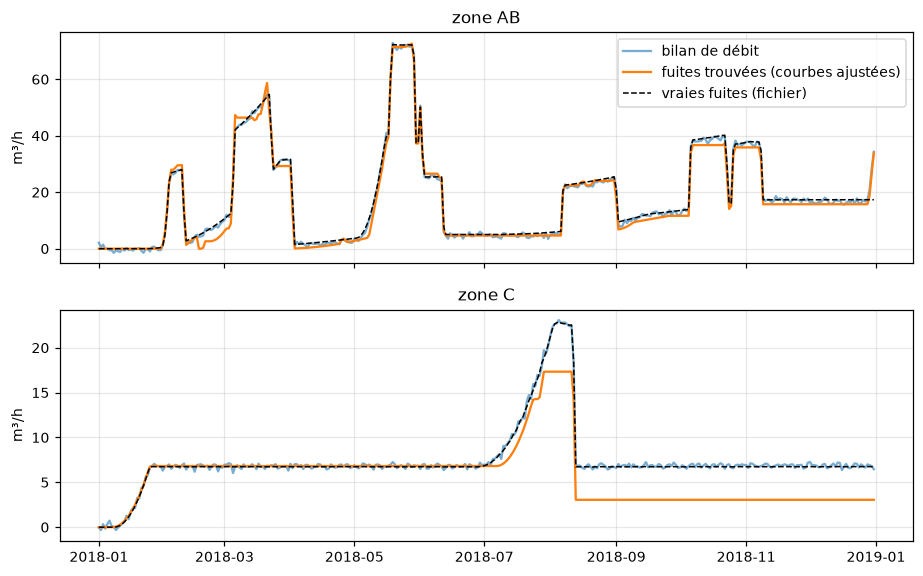

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
heures = pd.date_range(f"{ANNEE}-01-01", periods=365 * 24, freq="1h")
for ax, z in zip(axes, ("AB", "C")):
    estime = sum((k.debit(heures) for k in trouvees if k.zone == z), np.zeros(len(heures)))
    ax.plot(bilan[z].resample("1D").mean(), alpha=0.6, label="bilan de débit")
    ax.plot(pd.Series(estime, index=heures).resample("1D").mean(), label="fuites trouvées (courbes ajustées)")
    ax.plot(vraie[z].resample("1D").mean(), "k--", lw=1, label="vraies fuites (fichier)")
    ax.set(ylabel="m³/h", title=f"zone {z}")
axes[0].legend();

## 8. Le score de 2018

Le barème officiel. Deux façons de dater une alarme :

- **comme l'article** : l'heure de détection (c'est ce qu'ils ont envoyé à BattLeDIM, qui donnait
  l'année entière d'un coup) ;
- **ce qu'on sait à ce moment-là** : la conduite n'est choisie qu'à la fin de la fenêtre (2 à 14
  jours après l'alarme).

Repère : les mêmes instants, chacun sur une conduite tirée au hasard (200 tirages).

In [17]:
b = B.Bareme(ANNEE)
for nom, quand in [("à la détection (article)", lambda k: k.alarme),
                   ("fin de la fenêtre (causal)", lambda k: k.notes["fin_fenetre"])]:
    envois = [(k.conduite, quand(k)) for k in trouvees]
    n = b.noter(envois)
    m, s = b.hasard([t for _, t in envois])
    print(f"{nom:26s} N={len(envois):3d} | {n['score']:9.0f} € | trouvées {n['vraies']:2d} sur {len(b.fuites)} | "
          f"fausses {n['fausses']:2d} | hasard {m:8.0f} ± {s:6.0f} € | z {(n['score'] - m) / s:+.1f}")
print(f"plafond {b.plafond():.0f} €")

à la détection (article)   N= 34 |    103684 € | trouvées  8 sur 14 | fausses 16 | hasard    29281 ±  21941 € | z +3.4


fin de la fenêtre (causal) N= 34 |    114478 € | trouvées 10 sur 14 | fausses 15 | hasard    28001 ±  21152 € | z +4.1
plafond 178873 €


L'article annonce 4 fausses alarmes sur 2019 (sur une autre année : la comparaison n'est qu'un
ordre de grandeur). D'où viennent les nôtres ? Pour chaque alarme (datée à
la fin de la fenêtre) : est-elle à moins de 300 m d'une fuite qui coule ? Sinon, c'est une fausse.
On les range par débit ajusté, et selon qu'une alarme a **déjà** été envoyée à moins de 300 m.

In [18]:
lignes, deja = [], []
for k in sorted(trouvees, key=lambda k: k.notes["fin_fenetre"]):
    t = k.notes["fin_fenetre"]
    actives = [p for p in fuites.index if fuites.debut[p] <= t <= fuites.fin[p]]
    fausse = all(not distances.at[k.conduite, p] <= 300 for p in actives)
    repetee = any(distances.at[k.conduite, q] <= 300 for q in deja)
    deja.append(k.conduite)
    taille = "moins de 3 m³/h" if k.q_s < 3 else ("3 à 10 m³/h" if k.q_s < 10 else "10 m³/h et plus")
    lignes.append({"débit ajusté": taille, "fausse": fausse, "déjà envoyée à moins de 300 m": repetee})
ana = pd.DataFrame(lignes)
print(pd.crosstab(ana["débit ajusté"], ana["fausse"], margins=True).rename(columns={False: "près d'une fuite", True: "fausse"}).to_string())
print()
print(pd.crosstab(ana["déjà envoyée à moins de 300 m"], ana["fausse"]).rename(columns={False: "près d'une fuite", True: "fausse"}).to_string())

fausse           près d'une fuite  fausse  All
débit ajusté                                  
10 m³/h et plus                10       3   13
3 à 10 m³/h                     5       3    8
moins de 3 m³/h                 4       9   13
All                            19      15   34

fausse                         près d'une fuite  fausse
déjà envoyée à moins de 300 m                          
False                                         9       6
True                                         10       9


**Ce qui a été essayé pour se rapprocher de l'article** (même boucle sur 2018, une vingtaine de
minutes par ligne ; datées à la fin de la fenêtre) :

| version | alarmes | trouvées | fausses | euros | hasard | z |
|---|---|---|---|---|---|---|
| CUSUM, sans réajustement des fuites connues | 58 | 11 / 14 | 26 | 124 994 € | 36 222 ± 21 666 € | +4,1 |
| CUSUM + rapport de vraisemblance, sans réajustement | 64 | 10 / 14 | 35 | 106 087 € | 39 598 ± 21 773 € | +3,1 |
| CUSUM + réajustement (**ce carnet**) | 34 | 10 / 14 | 15 | 114 478 € | 28 001 ± 21 152 € | +4,1 |
| CUSUM + rapport de vraisemblance + réajustement | 39 | 8 / 14 | 25 | 68 546 € | 26 335 ± 23 301 € | +1,8 |

- Le **réajustement** des fuites connues (étape 4) retire 24 alarmes et 11 fausses : une fuite qui
  grandit encore met sa courbe à jour au lieu de sonner une deuxième fois.
- Le **rapport de vraisemblance** ajoute des alarmes, et surtout des fausses.
- **Monter les seuils** (l'article : seuils « réglés pour limiter le taux global de fausses
  alarmes ») ne suffit pas. Avec les deux tests et sans réajustement, multiplier la marge de 2 à 12
  fait passer les alarmes de 64 à 47, mais les fausses restent entre 25 et 35, et on perd des fuites :

| marge des seuils | 2 | 3 | 4 | 6 | 8 | 12 |
|---|---|---|---|---|---|---|
| alarmes | 64 | 52 | 58 | 56 | 54 | 47 |
| trouvées / 14 | 10 | 10 | 11 | 10 | 10 | 9 |
| fausses | 35 | 28 | 33 | 25 | 28 | 25 |
| euros | 106 087 | 92 791 | 97 137 | 106 085 | 83 785 | 75 997 |

## 9. Une vérification : la localisation seule

Pour séparer la localisation du reste de la boucle : chaque casse de 2018 (au moins 2 m³/h de plus
en un jour), localisée à partir de son **vrai** début (fichier publié), de trois façons :

- **l'article** : à chaque heure, seulement les capteurs dont `q_v` a monté d'au moins 0,5 L/s ;
- **tous les capteurs de la zone** : la même corrélation de Pearson, sur la baisse moyenne des 24 h ;
- **nos moindres carrés** (carnet b) : la signature dont l'amplitude ajustée colle le mieux.

In [19]:
qv_h, baisse = U.horaire(qv), -U.horaire(res)
dico = L.dictionnaire(2018, 1, 10.0)
vus = set(L.visibles(dico))
lignes = []
for p in fuites.index:
    t = instant(p)
    hausse = debits[p].loc[t:t + pd.Timedelta(days=1)].mean() - debits[p].loc[t - pd.Timedelta(days=1):t].mean()
    if hausse < 2:
        continue
    z, cap = fuites.zone[p], capteurs_de[fuites.zone[p]]
    cand = [c for c in L.conduites_de_zone(wn, z, list(dico.index)) if c in vus]
    article = U.localiser(baisse, qv_h, t, t + pd.Timedelta(days=2), cap, dico, cand)[0]
    r = (baisse.loc[t:t + pd.Timedelta(days=1), cap].mean() - baisse.loc[t - pd.Timedelta(days=1):t, cap].mean()).to_numpy()
    zone_entiere = cand[int(U.pearson(r, dico.loc[cand, cap].to_numpy()).argmax())]
    mc = L.vraisemblance(L.observer(res, t, 24), dico.loc[cand], sigma=0.6, relatif=0.06).proba.idxmax()
    lignes.append({"fuite": p, "hausse (m³/h)": round(hausse, 1),
                   "article (m)": metres(article, p),
                   "tous les capteurs (m)": metres(zone_entiere, p),
                   "moindres carrés (m)": metres(mc, p)})
verif = pd.DataFrame(lignes).set_index("fuite")
print("à moins de 300 m :", (verif.drop(columns="hausse (m³/h)") <= 300).sum().to_dict(), "sur", len(verif))
verif

à moins de 300 m : {'article (m)': 6, 'tous les capteurs (m)': 8, 'moindres carrés (m)': 8} sur 8


,hausse (m³/h),article (m),tous les capteurs (m),moindres carrés (m)
fuite,,,,
p158,23.1,166,0,0
p183,15.3,389,0,59
p232,10.9,205,101,101
p369,19.8,276,50,50
p538,30.6,39,85,96
p628,4.7,258,51,171
p673,27.0,229,179,139
p866,19.6,310,50,38


## À retenir

- **Le modèle dual** tourne sur notre modèle calibré. Tenu au modèle lui-même, `q_v` est nul. Coupé
  à la pompe comme dans l'article, le bruit de la zone C est divisé par quatre (1,27 → 0,31 m³/h).
- **La somme des `q_v`** d'une zone suit la fuite totale jour après jour (corrélation 0,99 à 1,00),
  un peu en dessous (−2,7 m³/h en AB, −2,1 en C), comme l'article le remarque.
- **Le signal est localisé** : pour une casse, le capteur qui réagit le plus porte 30 à 70 % de la
  marche de `q_v`, contre 6 à 14 % de la baisse de pression.
- **2018, de bout en bout** (34 alarmes, plafond 178 873 €) :
  - datées à la fin de la fenêtre : 10 fuites sur 14, 15 fausses alarmes, 114 478 € (hasard
    28 001 ± 21 152 €, z = +4,1) ;
  - datées à la détection, comme l'article : 8 sur 14, 16 fausses, 103 684 € (z = +3,4).
  Pour comparer, la chaîne des carnets a à c fait 129 102 € avec 95 alarmes, dont 49 fausses : la
  méthode de l'article garde l'essentiel des euros avec trois fois moins de fausses alarmes.
- **Ce qui rapproche de l'article** : réajuster les fuites connues avant d'en déclarer une nouvelle
  (26 → 15 fausses). Monter les seuils ou ajouter le rapport de vraisemblance n'aide pas sur nos données.
- **Ce qui reste loin** : 15 fausses alarmes contre leurs 4 (sur 2019, une autre année). 9 des 15 ont
  un débit ajusté sous 3 m³/h, et 9 tombent à moins de 300 m d'un endroit déjà envoyé.
- **La règle de localisation de l'article** (seulement les capteurs dont `q_v` monte d'au moins
  0,5 L/s) place 6 casses sur 8 à moins de 300 m ; la même corrélation sur tous les capteurs de la
  zone, 8 sur 8 (§9).
- Tout est réglé sur 2018. 2019 n'a pas encore été regardée : à faire une fois, avec les prédictions
  écrites avant.

Étapes suivantes : la détection (CUSUM et rapport de vraisemblance sur `q_v`), la forme de chaque
fuite, la localisation par corrélation, puis l'ajout des fuites trouvées au modèle.